In [15]:
import numpy as np
from graphs import env_graph
import matplotlib.pyplot as plt
import glob
import pandas as pd
from pathlib import Path
from scipy.optimize import curve_fit

In [16]:
def exp_model(t, M0, T1, phi):
   return M0 * (1 - np.exp(-t/T1)) + phi


def exp_regime(time, voltage):
    '''
    1. Isolate 2nd Regime
    2. Curve Fit model to data
    3. Return model
    '''
    p0 = [1.75,  # A: amplitude
      60,            # tau: a few times shorter than your window
      0.25] 
    popt, pcov = curve_fit(exp_model, time, voltage, p0=p0)
    perr = np.sqrt(np.diag(pcov))
    return popt, perr



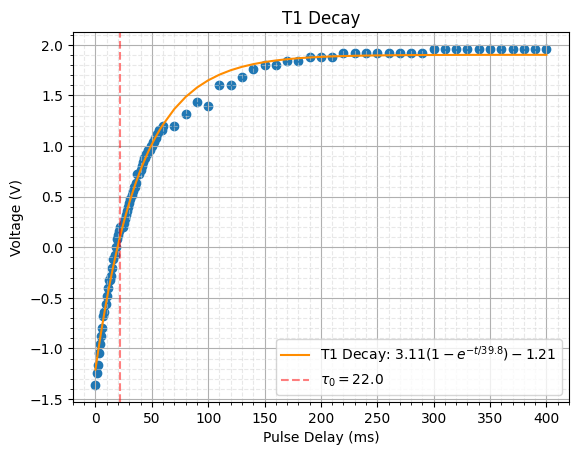

T1: 39.78491711287218 ± 0.5962338757716078 ms


In [18]:
files = glob.glob(f"Data/T1/*.csv") # Download files
files = sorted(files, key=lambda f: float(Path(f).stem))

results = []
for file in files:
    number = float(Path(file).stem)
    df = pd.read_csv(f"{file}", skiprows=20)

    voltage = df["CH1"]
    
    volt = np.max(voltage)
    
    results.append((number, volt))

time, volt = zip(*results)
time = np.array(time)
volt = np.array(volt)

idx = np.argmin(volt)
v_min = volt[idx]
volt_corrected = volt.copy()
volt_corrected[:idx] = 2*v_min - volt_corrected[:idx]

popt, perr = exp_regime(time, volt_corrected)

tau0 = time[np.argmin(volt)]


fig = plt.figure()
plt.scatter(time, volt_corrected)
plt.plot(time, exp_model(time, *popt), color='darkorange', label= f"T1 Decay: ${popt[0]:.2f}(1 - e^{{-t/{popt[1]:.1f}}}) {popt[2]:.2f} $")
plt.grid()
plt.minorticks_on()
plt.grid(visible=True, which='minor', color='lightgray', linestyle='--', alpha=0.5)

plt.axvline(tau0, color='red', linestyle='--', alpha=0.5, label = f"$\u03c4_0 = {tau0}$")


plt.xlabel("Pulse Delay (ms)")
plt.ylabel("Voltage (V)")
plt.title("T1 Decay")

plt.legend(loc='lower right')

fig.savefig(f"T1.png", dpi=300, bbox_inches="tight")

plt.show()

print(f'T1: {popt[1]} ± {perr[1]} ms')

